# Bank Customer Churn Analysis

## Analyze customer data to identify factors influencing churn and provide actionable insights to improve customer retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

In [2]:
df = pd.read_csv("bank_churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


## Data understanding
We explore the structure, data types and the basic statistics of the dataset

In [3]:
df.shape
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  str    
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  str    
 5   Gender              10000 non-null  str    
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card Type       

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


## Data cleaning
Handling missing values,removing unnecessary columns and fixing data types

In [4]:
#checking for duplicates
df.duplicated().sum()

#checking for missing values
df.isnull().sum()

#Dropping unnecessary columns
df.drop(['Surname'], axis = 1, inplace = True)

In [5]:

#Displaying CustomerId in float format with no decimal places
pd.options.display.float_format = '{:.0f}'.format

In [6]:
df.head()

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,619,France,Female,42,2,0,1,1,1,101349,1,1,2,DIAMOND,464
1,2,15647311,608,Spain,Female,41,1,83808,1,0,1,112543,0,1,3,DIAMOND,456
2,3,15619304,502,France,Female,42,8,159661,3,1,0,113932,1,1,3,DIAMOND,377
3,4,15701354,699,France,Female,39,1,0,2,0,0,93827,0,0,5,GOLD,350
4,5,15737888,850,Spain,Female,43,2,125511,1,1,1,79084,0,0,5,GOLD,425


In [7]:
df.rename(columns={'HasCrCard':'HasCreditCard'}, inplace=True)

In [8]:
#Age groups
df['AgeGroup']=pd.cut(df['Age'],bins=[17, 25, 40, 60, 100], labels=['18-25', '26-40','41-60', '60+'])

#Tenure groups
df['TenureGroup']=pd.cut(df['Tenure'],bins=[-1, 2, 5, 10], labels=['0-2', '3-5', '6-10'])

#Credit groups
df['CreditGroup']=pd.cut(df['CreditScore'],bins=[300, 450, 600, 900], labels=['Poor', 'Average', 'Good'])

#Balance groups
df['BalanceGroup'] = pd.cut(df['Balance'], bins=[-1, 50000, 120000, 251000], labels=['Low', 'Medium', 'High'])

#EstimatedSalary groups
df['EstimatedSalaryGroup']=pd.cut(df['EstimatedSalary'],bins=[-1, 50000, 100000, 150000], labels=['Low', 'Medium', 'High'])

#Point groups
df['PointGroup']=pd.cut(df['Point Earned'],bins=[118, 400, 700, 1001], labels=['Low', 'Medium', 'High'])

In [9]:
p = df['CreditScore'].max()
print(p)

850


In [10]:
df.head()

,RowNumber,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCreditCard,...,Complain,Satisfaction Score,Card Type,Point Earned,AgeGroup,TenureGroup,CreditGroup,BalanceGroup,EstimatedSalaryGroup,PointGroup
0,1,15634602,619,France,Female,42,2,0,1,1,...,1,2,DIAMOND,464,41-60,0-2,Good,Low,High,Medium
1,2,15647311,608,Spain,Female,41,1,83808,1,0,...,1,3,DIAMOND,456,41-60,0-2,Good,Medium,High,Medium
2,3,15619304,502,France,Female,42,8,159661,3,1,...,1,3,DIAMOND,377,41-60,6-10,Average,High,High,Low
3,4,15701354,699,France,Female,39,1,0,2,0,...,0,5,GOLD,350,26-40,0-2,Good,Low,Medium,Low
4,5,15737888,850,Spain,Female,43,2,125511,1,1,...,0,5,GOLD,425,41-60,0-2,Good,High,Medium,Medium


In [11]:
df.dtypes

RowNumber                  int64
CustomerId                 int64
CreditScore                int64
Geography                    str
Gender                       str
Age                        int64
Tenure                     int64
Balance                  float64
NumOfProducts              int64
HasCreditCard              int64
IsActiveMember             int64
EstimatedSalary          float64
Exited                     int64
Complain                   int64
Satisfaction Score         int64
Card Type                    str
Point Earned               int64
AgeGroup                category
TenureGroup             category
CreditGroup             category
BalanceGroup            category
EstimatedSalaryGroup    category
PointGroup              category
dtype: object

# Exploratory Data Analysis(EDA)


## Churn by Age-Groups

In [12]:
age_group = (df.groupby('AgeGroup')['Exited'].mean() * 100).round(2)
age_group.astype(str) + '%'

AgeGroup
18-25     7.53%
26-40    11.04%
41-60    39.65%
60+      24.78%
Name: Exited, dtype: str

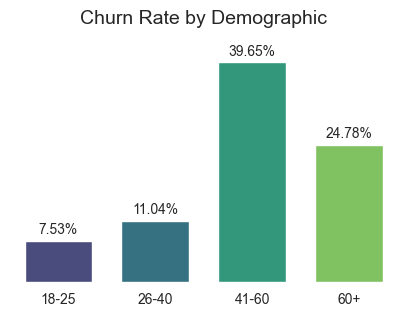

In [13]:
#Visualization
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='AgeGroup', y='Exited', data=df, hue='AgeGroup', palette='viridis', errorbar=None, dodge=False, width=0.7)

# Adding the data labels
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True) 

plt.title("Churn Rate by Demographic", fontsize=14, pad=20)
plt.show()

## Churn by Gender

In [14]:
df.groupby('Gender')['Exited'].mean() * 100

Gender
Female   25
Male     16
Name: Exited, dtype: float64

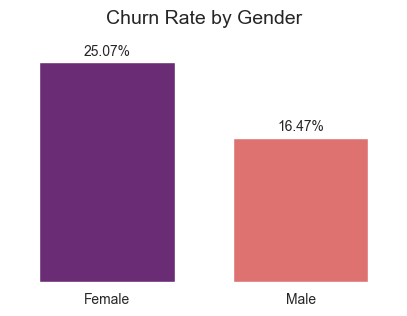

In [15]:
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='Gender', y='Exited', data=df, hue='Gender', palette='magma', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Gender", fontsize=14, pad=20)
plt.show()

## Churn By Geography

In [16]:
geo_churn = (df.groupby('Geography')['Exited'].mean() * 100).round(2)
geo_churn.sort_values(ascending=False)
geo_churn.astype(str) + '%'


Geography
France     16.17%
Germany    32.44%
Spain      16.67%
Name: Exited, dtype: str

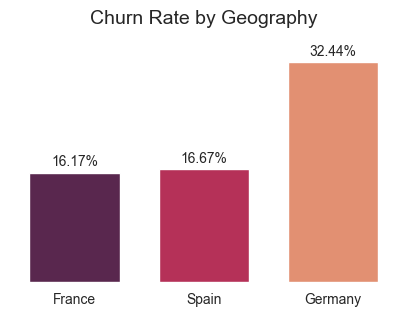

In [17]:
plt.figure(figsize=(5, 3))


ax = sns.barplot(x='Geography', y='Exited', data=df, hue='Geography', 
palette='rocket', errorbar=None, dodge=False, width=0.7)

for container in ax.containers:
      ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Geography", fontsize=14, pad=20)
plt.show()
plt.show()

## Churn by Credit Score

In [18]:
credit_score_churn = (df.groupby('CreditGroup')['Exited'].mean() * 100).round(2)
credit_score_churn.astype(str) + '%'

CreditGroup
Poor       32.28%
Average    20.99%
Good        19.8%
Name: Exited, dtype: str

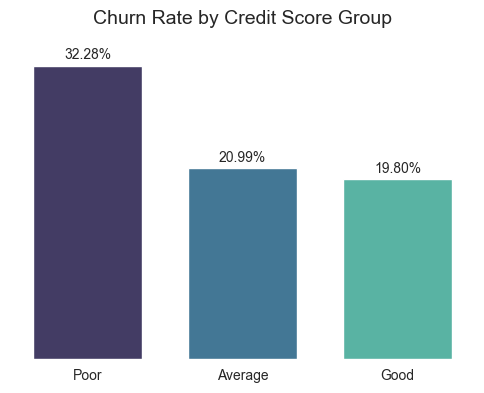

In [19]:
plt.figure(figsize=(6, 4))


ax = sns.barplot(x='CreditGroup', y='Exited', data=df, hue='CreditGroup', palette='mako', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Credit Score Group", fontsize=14, pad=20)
plt.show()


## Churn by Card Type

In [20]:
card_type_churn = (df.groupby('Card Type')['Exited'].mean() * 100).round(2)
card_type_churn.astype(str) + '%'

Card Type
DIAMOND     21.78%
GOLD        19.26%
PLATINUM    20.36%
SILVER      20.11%
Name: Exited, dtype: str

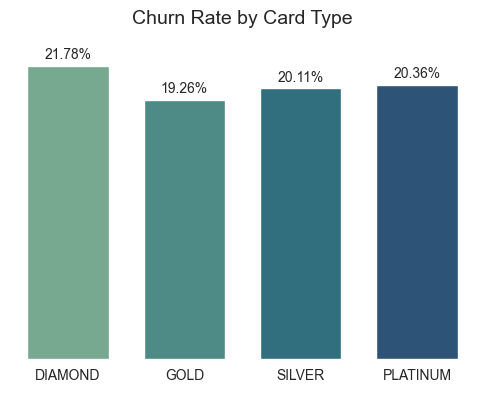

In [21]:
plt.figure(figsize=(6, 4))


ax = sns.barplot(x='Card Type', y='Exited', data=df, hue='Card Type', palette='crest', errorbar=None, dodge=False, width=0.7)


for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f'{x*100:.2f}%', padding=3)


plt.xlabel("")
plt.ylabel("")
ax.set_yticks([]) 
sns.despine(left=True, bottom=True)

plt.title("Churn Rate by Card Type", fontsize=14, pad=20)
plt.show()

## Satisfaction Score by Churn

In [22]:
satisfaction_score = (df.groupby('Satisfaction Score')['Exited'].mean() * 100).round(2)
satisfaction_score.astype(str) + '%'


Satisfaction Score
1    20.03%
2     21.8%
3    19.64%
4    20.62%
5    19.81%
Name: Exited, dtype: str

## Churn by Complaints

In [23]:
complaints = (df.groupby('Complain')['Exited'].mean() * 100).round(2)
complaints.astype(str) + '%'

Complain
0     0.05%
1    99.51%
Name: Exited, dtype: str

## Product Engagement vs Churn

In [24]:
product = (df.groupby('NumOfProducts')['Exited'].mean() * 100).round(2)
product.astype(str) + '%'

NumOfProducts
1    27.71%
2      7.6%
3    82.71%
4    100.0%
Name: Exited, dtype: str

## Churn VS Credit Card

In [25]:
credit_card = (df.groupby('HasCreditCard')['Exited'].mean() * 100).round(2)
credit_card.astype(str) + '%'

HasCreditCard
0    20.81%
1     20.2%
Name: Exited, dtype: str

## Churn by Active Membership

In [26]:
active_membership = (df.groupby('IsActiveMember')['Exited'].mean() * 100).round(2)
active_membership.astype(str) + '%'

IsActiveMember
0    26.87%
1    14.27%
Name: Exited, dtype: str

## Churn by Average Salary

In [27]:
average_salary = (df.groupby('EstimatedSalaryGroup')['Exited'].mean() * 100).round(2)
average_salary.astype(str) + '%'

EstimatedSalaryGroup
Low       19.93%
Medium    19.87%
High      20.23%
Name: Exited, dtype: str

## Churn by Average Balance

In [28]:
average_balance = (df.groupby('BalanceGroup')['Exited'].mean() * 100).round(2)
average_balance.astype(str) + '%'


BalanceGroup
Low       14.25%
Medium    23.89%
High      24.05%
Name: Exited, dtype: str

## Churn by Tenure

In [29]:
tenure = (df.groupby('TenureGroup')['Exited'].mean() * 100).round(2)
tenure.astype(str) + '%'    

TenureGroup
0-2     21.15%
3-5     20.76%
6-10    19.69%
Name: Exited, dtype: str

## Points Earned vs Churn

In [30]:
point_earned = (df.groupby('PointGroup')['Exited'].mean()*100).round(2)
point_earned.astype(str) + '%'

PointGroup
Low       21.04%
Medium    19.86%
High       20.5%
Name: Exited, dtype: str

## Churn Risk Profile

In [31]:
risk_profile = (df.groupby(['IsActiveMember','Complain'])['Exited'].mean() * 100).round(2)
risk_profile.astype(str) + '%'

IsActiveMember  Complain
0               0            0.11%
                1           99.69%
1               0             0.0%
                1           99.19%
Name: Exited, dtype: str

#  KPI Calculations
##  Overall Churn Rate

In [32]:
churn_rate = (df['Exited'].mean() * 100).round(2)
churn_rate.astype(str)
print(f"Overall churn rate = {churn_rate}{'%'}")

Overall churn rate = 20.38%


## % of Churned Customers with Complaints

In [33]:
churn_complaint = (df[df['Exited']==1]['Complain'].mean() * 100).round(2)
churn_complaint.astype(str)
print(f"% of Churned Customers with Complaints = {churn_complaint}{'%'}")

% of Churned Customers with Complaints = 99.8%


## Average Credit Score (Churned vs Retained)

In [34]:
df.groupby('Exited')['CreditScore'].mean()


Exited
0   652
1   645
Name: CreditScore, dtype: float64

## Satisfaction Distribution

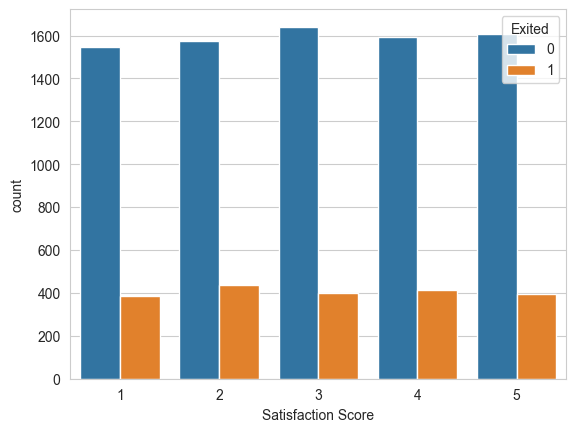

In [35]:
sns.countplot(x='Satisfaction Score', hue='Exited', data=df)
plt.show()